# RecetaExpress

**POC de Prompt Engineering para recomendación de recetas a partir de ingredientes disponibles**

Autor: FrancoFEFA · Repositorio: https://github.com/FrancoFEFA/RecetaExpress


## 2. Descripción del proyecto

RecetaExpress es una prueba de concepto que, a partir de los ingredientes que una persona tiene en casa, sugiere recetas realistas clasificadas en tres grupos:

1. **Recetas disponibles actualmente** (0 ingredientes faltantes).
2. **Recetas que requieren exactamente 1 ingrediente adicional**.
3. **Recetas que requieren hasta 2 ingredientes adicionales**.

Además, permite simular el **descubrimiento progresivo**: mostrar qué nuevos platos aparecen a medida que se agregan ingredientes. La POC demuestra el uso de técnicas de *Fast Prompting* para transformar una consulta simple en una respuesta estructurada, validada y útil, y conecta un modelo texto→texto con un generador de imágenes gratuito (texto→imagen).


## 3. Problemática

Muchas personas tienen ingredientes en su despensa pero no saben qué cocinar con ellos. Las búsquedas tradicionales en internet requieren decidir de antemano qué plato se quiere hacer, lo cual es justamente lo que no se sabe. También es difícil predecir qué nuevas recetas se desbloquean al comprar un ingrediente extra. Esto genera desperdicio de alimentos, decisiones de último momento y comidas repetitivas.

Resolver este problema con IA es relevante porque reduce el desperdicio, ahorra tiempo y dinero, y empodera a cualquier persona para cocinar con lo que ya tiene.


## 4. Justificación

La solución se apoya en modelos de lenguaje (LLM) porque pueden razonar sobre combinaciones de ingredientes y producir texto estructurado. Sin embargo, un LLM crudo tiende a inventar ingredientes, clasificar mal las recetas y repetir platos. Por eso se aplican técnicas de *Prompt Engineering* para controlar la salida y una capa de validación determinística para garantizar la coherencia.

La viabilidad técnica es alta: se usan herramientas gratuitas o de capa gratuita (Gemini API, Pollinations para imágenes, edge-tts para audio), el proyecto cabe en un par de días de trabajo y no requiere infraestructura adicional.


## 5. Objetivo general

Demostrar que mediante técnicas de *Fast Prompting* se puede convertir una consulta simple basada en ingredientes en una respuesta estructurada, útil y controlada, capaz de alimentar un generador de imágenes y una narración de audio.


## 6. Objetivos específicos

- Diseñar tres versiones de prompt (básico, mejorado y optimizado) y comparar sus resultados.
- Validar la respuesta del LLM para evitar ingredientes inventados y clasificaciones inconsistentes.
- Implementar un descubrimiento progresivo de recetas al agregar ingredientes.
- Generar una imagen representativa de una receta usando un modelo texto→imagen gratuito.
- Evaluar objetivamente las versiones de prompt con métricas reproducibles.
- Documentar todo en una Jupyter Notebook funcional y un repositorio de GitHub.


## 7. Tecnologías utilizadas

| Tecnología | Uso |
|---|---|
| Python 3.14 | Lenguaje principal |
| Jupyter Notebook | Narrativa interactiva con código, texto e imágenes |
| `google-genai` | Cliente de Gemini (texto→texto) |
| `requests` | Llamadas a Pollinations (texto→imagen) |
| `edge-tts` | Narración de audio sin API key |
| `pandas` | Tablas de evaluación |
| `matplotlib` | Gráficos comparativos |
| `python-dotenv` | Gestión segura de la API key |
| `unidecode` | Normalización de ingredientes |


## 8. Arquitectura de la solución

```
Usuario
  │
  ▼
[Selección de ingredientes] ──► [Prompt Engineering]
                                     │
                                     ▼
                              [LLM texto→texto]
                                     │
                    ┌────────────────┼────────────────┐
                    ▼                ▼                ▼
         [Validación JSON]  [Reclasificación]  [Filtrado de duplicados]
                    │                │                │
                    └────────────────┼────────────────┘
                                   ▼
                         [Recetas estructuradas]
                                   │
                    ┌──────────────┼──────────────┐
                    ▼              ▼              ▼
            [Evaluación]   [Texto→imagen]   [Texto→audio]
```

La capa de validación es clave: el modelo propone, pero el código decide la categoría real (A/B/C), detecta ingredientes inventados y elimina duplicados.


In [1]:
# 9. Datos de entrada
import sys
import json
import os
from pathlib import Path

# Asegurar que se encuentren los módulos locales
sys.path.insert(0, "src")

from dotenv import load_dotenv
load_dotenv()

from recetaexpress.recetas import cargar_ingredientes, ingredientes_a_canonical
from recetaexpress.config import BASICOS_DESPENSA

datos = cargar_ingredientes()
catalogo = datos["catalogo"]
escenarios = datos["escenarios"]

print("Catálogo de ingredientes:")
for item in catalogo:
    print(f"  - {item['canonical']}")

print(f"\nBásicos de despensa: {BASICOS_DESPENSA}")
print(f"\nEscenarios definidos:")
for k, v in escenarios.items():
    print(f"  {k}: {v}")


Catálogo de ingredientes:
  - pollo
  - arroz
  - cebolla
  - tomate
  - huevo
  - papa
  - queso
  - zanahoria
  - ajo
  - morrón
  - espinaca
  - leche
  - harina
  - pan
  - limón

Básicos de despensa: {'agua', 'pimienta', 'aceite', 'azucar', 'sal'}

Escenarios definidos:
  pocos: ['pollo', 'arroz', 'cebolla']
  intermedio: ['pollo', 'arroz', 'cebolla', 'tomate', 'huevo', 'papa', 'queso']
  progresivo: {'paso_1': ['pollo', 'arroz', 'cebolla'], 'paso_2': ['pollo', 'arroz', 'cebolla', 'huevo'], 'paso_3': ['pollo', 'arroz', 'cebolla', 'huevo', 'tomate']}


## 10. Prompt inicial

La primera versión representa una consulta típica y deliberadamente simple. Se espera que la respuesta sea poco controlada.


In [2]:
# 10. Prompt inicial
from recetaexpress.prompts import PROMPT_BASICO
from recetaexpress.recetas import construir_prompt

ingredientes_pocos = escenarios["pocos"]
prompt_basico = construir_prompt("basico", ingredientes_pocos)
print(prompt_basico)


Tengo estos ingredientes: arroz, cebolla, pollo.
¿Qué recetas puedo preparar? Devuélveme la respuesta en formato JSON con tres listas: recetas_disponibles, recetas_un_ingrediente y recetas_dos_ingredientes.
Cada receta debe tener nombre, descripcion, ingredientes_utilizados, ingredientes_faltantes, tiempo, dificultad y aprovechamiento.


## 11. Resultado inicial

Ejecutamos el prompt básico contra el modelo de texto. Si no hay API key configurada, se usa un proveedor gratuito de respaldo para que la notebook siga siendo funcional.


In [3]:
# 11. Resultado inicial
from recetaexpress.llm import generate_text

# Determinar proveedor según disponibilidad de API key real (no placeholder)
key = os.getenv("GEMINI_API_KEY", "").strip()
provider = "gemini" if key and "TU_API_KEY" not in key else "pollinations"
print(f"Proveedor activo: {provider}")

resultado_basico = generate_text(prompt_basico, provider=provider)
print("\n--- Respuesta cruda ---")
print(resultado_basico[0][:1500])


Proveedor activo: gemini



--- Respuesta cruda ---
{
  "recetas_disponibles": [
    {
      "nombre": "Arroz salteado con pollo y cebolla",
      "descripcion": "Salteado rápido donde la cebolla pochada carameliza ligeramente para acompañar dados de pollo dorados sobre una base de arroz blanco.",
      "ingredientes_utilizados": ["arroz", "cebolla", "pollo"],
      "ingredientes_faltantes": [],
      "tiempo": "25 minutos",
      "dificultad": "Fácil",
      "aprovechamiento": "Utiliza los tres ingredientes al 100%, ideal si se cuenta con arroz sobrante previamente cocido."
    },
    {
      "nombre": "Pollo encebollado con arroz blanco",
      "descripcion": "Guiso sencillo de pollo cocinado a fuego lento sobre una cama abundante de cebolla pochada, servido con arroz como guarnición.",
      "ingredientes_utilizados": ["pollo", "cebolla", "arroz"],
      "ingredientes_faltantes": [],
      "tiempo": "35 minutos",
      "dificultad": "Fácil",
      "aprovechamiento": "Aprovecha los jugos del pollo y la cebolla

## 12. Análisis de limitaciones

Parseamos y validamos la respuesta del prompt básico. Se esperan problemas como ingredientes inventados, clasificación inconsistente o recetas repetidas.


In [4]:
# 12. Análisis de limitaciones
from recetaexpress.recetas import parsear_respuesta, validar_respuesta

respuesta_cruda_basico = parsear_respuesta(resultado_basico[0])
validado_basico = validar_respuesta(respuesta_cruda_basico, ingredientes_pocos, BASICOS_DESPENSA, catalogo)

print("Errores detectados por la validación:")
for err in validado_basico["errores"]:
    print(f"  - {err}")

print(f"\nRecetas disponibles: {len(validado_basico['respuesta']['recetas_disponibles'])}")
print(f"Recetas con 1 faltante: {len(validado_basico['respuesta']['recetas_un_ingrediente'])}")
print(f"Recetas con 2 faltantes: {len(validado_basico['respuesta']['recetas_dos_ingredientes'])}")


Errores detectados por la validación:
  - Receta 'Arroz con pollo al curry' inventó ingredientes: {'curry en polvo'}
  - Receta 'Arroz frito estilo oriental con pollo' inventó ingredientes: {'salsa de soja'}
  - Receta 'Arroz con pollo y zanahoria' inventó ingredientes: {'zanahoria'}
  - Receta 'Pollo a la crema con champiñones y arroz' inventó ingredientes: {'nata para cocinar', 'champinones'}
  - Receta 'Arroz con pollo a la española' inventó ingredientes: {'morron', 'azafran o colorante alimentario'}
  - Receta 'Risotto rápido de pollo y queso' inventó ingredientes: {'queso parmesano', 'caldo de verduras'}

Recetas disponibles: 1
Recetas con 1 faltante: 0
Recetas con 2 faltantes: 0


## 13. Fast Prompting

Aplicamos técnicas de *Fast Prompting* para mejorar la calidad de la respuesta:

- **Role prompting**: asignar un rol experto (chef).
- **Contexto y objetivo**: describir quién usa el sistema y para qué.
- **Instrucciones específicas**: pasos concretos y numerados.
- **Restricciones**: qué no debe hacer el modelo.
- **Formato estructurado**: JSON con campos obligatorios.
- **Ejemplos**: ilustran la lógica de clasificación.
- **Prevención de alucinaciones**: normalización y validación posterior.


## 14. Prompt mejorado

Segunda versión: agregamos contexto, objetivo, restricciones y estructura de salida.


In [5]:
# 14. Prompt mejorado
from recetaexpress.recetas import generar_recomendaciones

prompt_mejorado = construir_prompt("mejorado", ingredientes_pocos)
print(prompt_mejorado)


Contexto: soy un usuario en casa que quiere cocinar sin ir al supermercado.
Objetivo: dada la lista de ingredientes disponibles, sugerir recetas realistas que pueda preparar ahora o con 1 o 2 ingredientes adicionales.
Ingredientes disponibles: arroz, cebolla, pollo.
Ingredientes básicos de despensa (siempre disponibles, no cuentan como faltantes): aceite, agua, azucar, pimienta, sal.
Restricciones:
- No inventes ingredientes que no estén en la lista de disponibles o básicos.
- Indica claramente los ingredientes faltantes.
- Evita recetas repetidas o prácticamente iguales.
- Prioriza recetas que aprovechen la mayor cantidad de ingredientes disponibles.
- No des cantidades absurdas.
Estructura de salida (JSON estricto):
{
  "recetas_disponibles": [...],
  "recetas_un_ingrediente": [...],
  "recetas_dos_ingredientes": [...]
}
Cada receta: nombre, descripcion, ingredientes_utilizados, ingredientes_faltantes, tiempo, dificultad, aprovechamiento.


In [6]:
# Ejecutar prompt mejorado
cliente_llm = lambda p, **kw: generate_text(p, provider=provider, **kw)

resultado_mejorado = generar_recomendaciones(
    cliente_llm,
    "mejorado",
    ingredientes_pocos,
    catalogo,
    BASICOS_DESPENSA,
)

print("Errores:", resultado_mejorado["errores"])
print("Recetas disponibles:", len(resultado_mejorado["respuesta_validada"]["recetas_disponibles"]))
print("Recetas con 1 faltante:", len(resultado_mejorado["respuesta_validada"]["recetas_un_ingrediente"]))
print("Recetas con 2 faltantes:", len(resultado_mejorado["respuesta_validada"]["recetas_dos_ingredientes"]))


Errores: ["Receta 'Arroz frito estilo oriental con pollo' inventó ingredientes: {'salsa de soja'}", "Receta 'Pollo al limón con arroz al vapor' inventó ingredientes: {'limon'}", "Receta 'Pollo en salsa de tomate y orégano con guarnición de arroz' inventó ingredientes: {'tomate triturado (o salsa de tomate)', 'oregano seco'}", "Receta 'Curry suave de pollo y verduras con arroz' inventó ingredientes: {'curry en polvo', 'zanahoria'}"]
Recetas disponibles: 2
Recetas con 1 faltante: 0
Recetas con 2 faltantes: 0


## 15. Prompt optimizado

Tercera versión: aplica todas las técnicas de *Fast Prompting* (rol, contexto, objetivo, instrucciones específicas, restricciones, criterios de priorización, clasificación, formato estructurado, ejemplo y prevención de información inventada).


In [7]:
# 15. Prompt optimizado
prompt_optimizado = construir_prompt("optimizado", ingredientes_pocos)
print(prompt_optimizado)


Rol: actúa como chef experto en cocina del hogar, nutrición y aprovechamiento de alimentos.
Contexto: el usuario tiene una despensa limitada y quiere maximizar el uso de lo que ya tiene, descubriendo recetas nuevas a medida que consigue más ingredientes.
Objetivo: generar sugerencias de recetas clasificadas según cuántos ingredientes adicionales (de la lista de disponibles) requiere cada una: 0, 1 o 2. Los ingredientes básicos de despensa no cuentan como faltantes.
Ingredientes disponibles: arroz, cebolla, pollo.
Ingredientes básicos de despensa (siempre disponibles, no se listan como faltantes): aceite, agua, azucar, pimienta, sal.
Instrucciones específicas:
1. Devuelve SOLO recetas culinariamente plausibles y seguras.
2. Para cada receta lista TODOS sus ingredientes, incluyendo disponibles y básicos.
3. Indica exactamente qué ingredientes faltan de la lista de disponibles (excluyendo básicos).
4. La clasificación se determina por len(ingredientes_faltantes): 0 → recetas_disponibles, 

In [8]:
# Ejecutar prompt optimizado
resultado_optimizado = generar_recomendaciones(
    cliente_llm,
    "optimizado",
    ingredientes_pocos,
    catalogo,
    BASICOS_DESPENSA,
)

print("Errores:", resultado_optimizado["errores"])
print("Recetas disponibles:", len(resultado_optimizado["respuesta_validada"]["recetas_disponibles"]))
print("Recetas con 1 faltante:", len(resultado_optimizado["respuesta_validada"]["recetas_un_ingrediente"]))
print("Recetas con 2 faltantes:", len(resultado_optimizado["respuesta_validada"]["recetas_dos_ingredientes"]))

# Mostrar la primera receta de cada categoría
for cat in ["recetas_disponibles", "recetas_un_ingrediente", "recetas_dos_ingredientes"]:
    if resultado_optimizado["respuesta_validada"][cat]:
        r = resultado_optimizado["respuesta_validada"][cat][0]
        print(f"\n{cat}: {r['nombre']}")
        print(f"  Usados: {r['ingredientes_utilizados']}")
        print(f"  Faltantes: {r['ingredientes_faltantes']}")
        print(f"  Aprovechamiento: {r['aprovechamiento']}%")


Errores: ["Receta 'Arroz con pollo al ajo aromático' inventó ingredientes: {'ajo'}", "Receta 'Pollo entomatado con guarnición de arroz' inventó ingredientes: {'tomate'}", "Receta 'Arroz frito estilo oriental con pollo' inventó ingredientes: {'salsa de soya', 'huevo'}", "Receta 'Pollo al curry rápido con arroz blanco' inventó ingredientes: {'leche de coco', 'curry en polvo'}"]
Recetas disponibles: 2
Recetas con 1 faltante: 1
Recetas con 2 faltantes: 1

recetas_disponibles: Arroz con pollo clásico en sartén
  Usados: ['aceite', 'agua', 'arroz', 'cebolla', 'pimienta', 'pollo', 'sal']
  Faltantes: []
  Aprovechamiento: 100.0%

recetas_un_ingrediente: Arroz con pollo al ajo aromático
  Usados: ['aceite', 'agua', 'arroz', 'cebolla', 'pimienta', 'pollo', 'sal']
  Faltantes: ['ajo']
  Aprovechamiento: 100.0%

recetas_dos_ingredientes: Arroz frito estilo oriental con pollo
  Usados: ['aceite', 'arroz', 'cebolla', 'pimienta', 'pollo', 'sal']
  Faltantes: ['huevo', 'salsa de soya']
  Aprovechamie

## 16. Comparación de prompts

Comparamos las tres versiones con métricas objetivas calculadas en código.


In [9]:
# 16. Comparación de prompts
from IPython.display import display
from recetaexpress.evaluacion import comparar_prompts, graficar_comparacion

resultados = {
    "basico": {
        "respuesta_validada": validado_basico["respuesta"],
        "errores": validado_basico["errores"],
        "metadata": resultado_basico[1],
    },
    "mejorado": resultado_mejorado,
    "optimizado": resultado_optimizado,
}

df_comparacion = comparar_prompts(resultados, ingredientes_pocos, catalogo, BASICOS_DESPENSA)
display(df_comparacion)

grafico_path = graficar_comparacion(df_comparacion)
print(f"\nGráfico guardado en: {grafico_path}")


,version_prompt,n_recetas,estructura_completa_pct,ingredientes_inventados,categoria_correcta_pct,variedad_firmas,aprovechamiento_promedio,n_errores_validacion,latencia_s
0,basico,1,100,0,100.0,1,100.00,6,7.886
1,mejorado,2,100,0,100.0,2,100.00,4,6.965
2,optimizado,4,100,3,100.0,3,91.67,4,13.495



Gráfico guardado en: C:\Users\USUARIO\Desktop\IA Generacion Prompts\images\comparacion_prompts.png


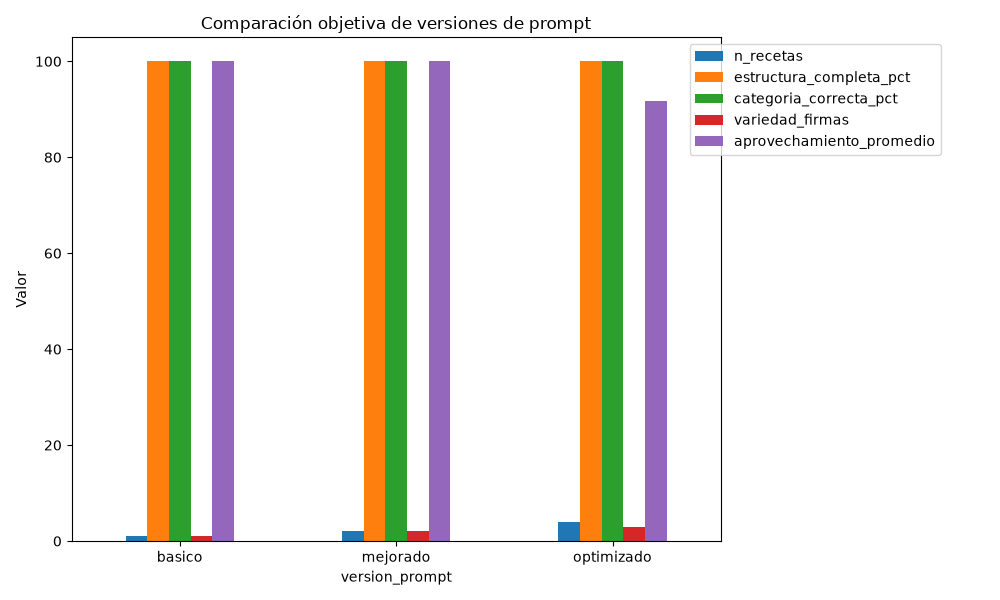

In [10]:
# Mostrar gráfico de comparación
from IPython.display import Image, display
display(Image(filename=grafico_path))


## 17. Evaluación

Evaluación de dos capas:
1. **Métricas objetivas** (calculadas en código): estructura, fidelidad de ingredientes, categoría correcta, variedad, aprovechamiento.
2. **LLM-as-judge** (método subjetivo auxiliar): rúbrica anclada 1-5 sobre claridad, relevancia, cumplimiento, uso de ingredientes, estructura, variedad y utilidad.

> **Nota metodológica:** el juez es un evaluador auxiliar; las conclusiones principales se basan en las métricas objetivas. Con n=3 escenarios, las conclusiones son indicativas, no estadísticamente significativas.


In [11]:
# 17. Evaluación con métricas objetivas y juez
from recetaexpress.evaluacion import metricas_objetivas, evaluar_con_juez

# Métricas del prompt optimizado
metricas = metricas_objetivas(resultado_optimizado["respuesta_validada"], ingredientes_pocos, catalogo, BASICOS_DESPENSA)
print("Métricas objetivas del prompt optimizado:")
for k, v in metricas.items():
    print(f"  {k}: {v}")

# Evaluación con juez (solo si hay API key, para no gastar cuota del fallback)
if os.getenv("GEMINI_API_KEY"):
    eval_juez, meta_juez = evaluar_con_juez(
        lambda p, **kw: generate_text(p, provider="gemini", **kw),
        json.dumps(resultado_optimizado["respuesta_validada"], ensure_ascii=False, indent=2),
    )
    print("\nEvaluación del juez:")
    for criterio, vals in eval_juez["criterios"].items():
        print(f"  {criterio}: {vals['nota']}/5 - {vals['justificacion']}")
else:
    print("\n[Omitido] No hay GEMINI_API_KEY; el juez requiere el modelo Gemini.")


Métricas objetivas del prompt optimizado:
  n_recetas: 4
  estructura_completa_pct: 100
  ingredientes_inventados: 3
  categoria_correcta_pct: 100.0
  variedad_firmas: 3
  aprovechamiento_promedio: 91.67



Evaluación del juez:
  claridad: 4/5 - Las descripciones como 'Guiso sencillo donde el pollo se dora junto a la cebolla...' son claras y concisas, aunque se beneficiarían de incluir pasos de preparación detallados.
  relevancia: 5/5 - Las recetas se adaptan de forma óptima a los ingredientes base reportados (pollo, arroz, cebolla y condimentos).
  cumplimiento_instrucciones: 5/5 - Clasifica con precisión las recetas según disponibilidad: 0 faltantes en 'recetas_disponibles', 1 en 'recetas_un_ingrediente' (ajo) y 2 en 'recetas_dos_ingredientes' (huevo, salsa de soya).
  uso_ingredientes: 5/5 - Respeta los ingredientes disponibles y registra de manera transparente los ingredientes faltantes/no disponibles en 'ingredientes_faltantes' e 'ingredientes_inventados_detectados'.
  estructura: 5/5 - El formato JSON es válido, consistente y posee tipos de datos adecuados (números flotantes para aprovechamiento, booleanos y listas).
  variedad: 3/5 - Presenta preparaciones distintas (guiso, salte

## 18. Texto → Imagen

Seleccionamos una receta del prompt optimizado y usamos el modelo texto→texto como intermediario para generar un prompt visual en inglés. Luego descargamos la imagen desde Pollinations (herramienta gratuita).


Receta elegida: Arroz con pollo clásico en sartén
Ingredientes: ['aceite', 'agua', 'arroz', 'cebolla', 'pimienta', 'pollo', 'sal']



Prompt visual (ES): Fotografía gastronómica profesional de un arroz con pollo clásico en sartén, presentado elegantemente en una sartén rústica de hierro fundido sobre una mesa de madera cálida y envejecida. Piezas de pollo doradas, tiernas y selladas con piel crujiente y brillante, dispuestas sobre arroz sazonado y esponjoso, con cebolla caramelizada translúcida visible y pimienta negra recién molida. Iluminación natural suave y difusa proveniente de una ventana lateral, creando sombras delicadas y brillos apetitosos en el pollo y los granos de arroz. Toma en ángulo de 45 grados con profundidad de campo reducida. Ambiente cálido y acogedor de cocina casera, ambientado con un paño de lino en tonos tierra en el fondo desenfocado. Calidad de revista culinaria, texturas nítidas, paleta de colores cálida y rica, sin personas, sin texto, sin logotipos.
Prompt visual (EN): Professional food photography of classic skillet chicken and rice, beautifully presented inside a rustic cast-iron skil

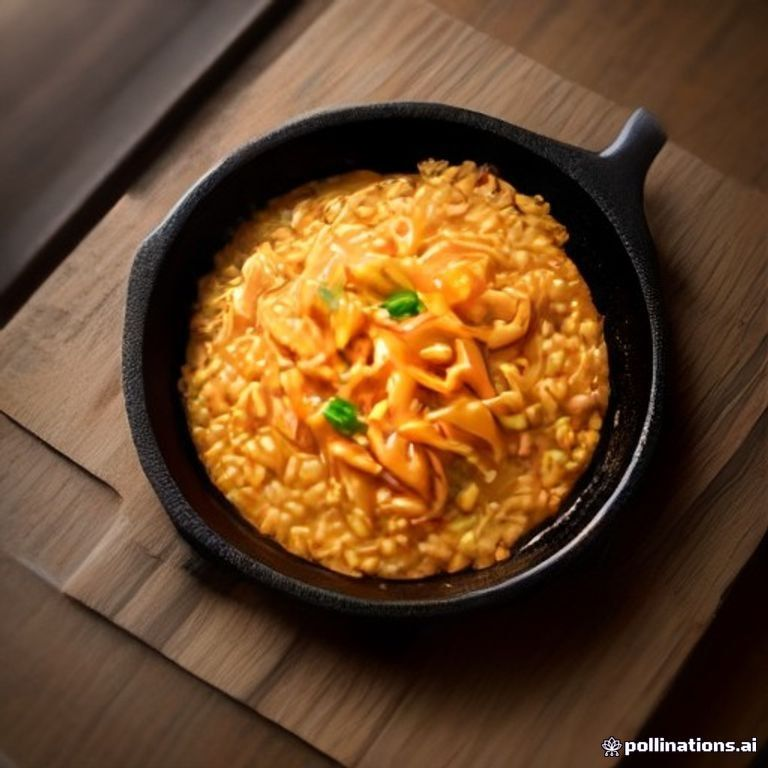

In [12]:
# 18. Texto → Imagen
from recetaexpress.imagenes import generar_imagen
from IPython.display import Image as IPImage, display

# Elegir la primera receta disponible (o la primera de cualquier categoría)
receta_elegida = None
for cat in ["recetas_disponibles", "recetas_un_ingrediente", "recetas_dos_ingredientes"]:
    if resultado_optimizado["respuesta_validada"][cat]:
        receta_elegida = resultado_optimizado["respuesta_validada"][cat][0]
        break

print(f"Receta elegida: {receta_elegida['nombre']}")
print(f"Ingredientes: {receta_elegida['ingredientes_utilizados']}")

imagen_info = generar_imagen(
    cliente_llm,
    receta_elegida,
    provider_texto=provider,
    seed=42,
)

print(f"\nPrompt visual (ES): {imagen_info['prompt_es']}")
print(f"Prompt visual (EN): {imagen_info['prompt_en']}")
print(f"Imagen guardada en: {imagen_info['ruta_imagen']}")

display(IPImage(filename=imagen_info['ruta_imagen']))


## 19. Resultados

Resumen de los tres escenarios experimentales y del descubrimiento progresivo.


In [13]:
# 19. Resultados - Escenarios
from recetaexpress.recetas import descubrimiento_progresivo

escenarios_a_correr = {
    "pocos": escenarios["pocos"],
    "intermedio": escenarios["intermedio"],
}

resultados_escenarios = {}
for nombre, ingredientes in escenarios_a_correr.items():
    res = generar_recomendaciones(
        cliente_llm,
        "optimizado",
        ingredientes,
        catalogo,
        BASICOS_DESPENSA,
    )
    resultados_escenarios[nombre] = res
    print(f"\nEscenario '{nombre}' ({ingredientes}):")
    print(f"  Disponibles: {len(res['respuesta_validada']['recetas_disponibles'])}")
    print(f"  1 faltante: {len(res['respuesta_validada']['recetas_un_ingrediente'])}")
    print(f"  2 faltantes: {len(res['respuesta_validada']['recetas_dos_ingredientes'])}")
    print(f"  Errores: {len(res['errores'])}")



Escenario 'pocos' (['pollo', 'arroz', 'cebolla']):
  Disponibles: 2
  1 faltante: 1
  2 faltantes: 1
  Errores: 4



Escenario 'intermedio' (['pollo', 'arroz', 'cebolla', 'tomate', 'huevo', 'papa', 'queso']):
  Disponibles: 3
  1 faltante: 2
  2 faltantes: 2
  Errores: 4


In [14]:
# Descubrimiento progresivo
secuencia = [
    ("Paso 1: base", escenarios["progresivo"]["paso_1"]),
    ("Paso 2: +huevo", escenarios["progresivo"]["paso_2"]),
    ("Paso 3: +tomate", escenarios["progresivo"]["paso_3"]),
]

progresivo = descubrimiento_progresivo(
    cliente_llm,
    "optimizado",
    secuencia,
    catalogo,
    BASICOS_DESPENSA,
)

for paso in progresivo:
    print(f"\n{paso['paso']}")
    print(f"  Ingredientes: {paso['ingredientes']}")
    print(f"  Total de recetas: {paso['total_recetas']}")
    print(f"  Nuevas recetas: {paso['novedades']}")



Paso 1: base
  Ingredientes: ['pollo', 'arroz', 'cebolla']
  Total de recetas: 4
  Nuevas recetas: ['Arroz con pollo al ajo aromático', 'Arroz con pollo clásico en sartén', 'Arroz frito estilo oriental con pollo', 'Salteado de pollo con cebolla caramelizada']

Paso 2: +huevo
  Ingredientes: ['pollo', 'arroz', 'cebolla', 'huevo']
  Total de recetas: 3
  Nuevas recetas: ['Arroz chaufa casero con salsa de soja', 'Arroz especial frito con verduras y salsa de soja', 'Arroz salteado con pollo, huevo y cebolla']

Paso 3: +tomate
  Ingredientes: ['pollo', 'arroz', 'cebolla', 'huevo', 'tomate']
  Total de recetas: 4
  Nuevas recetas: ['Arroz a la cubana con salsa de tomate y huevo frito', 'Arroz salteado completo con pollo, huevo, tomate y cebolla', 'Huevos revueltos pericos con tomate y cebolla', 'Pollo entomatado con cebolla']


## 20. Limitaciones del sistema

- El conocimiento culinario del modelo tiene fecha de corte; puede desconocer recetas regionales.
- La validación depende del catálogo y alias definidos; ingredientes fuera del catálogo se tratan como no disponibles.
- El generador de imágenes gratuito (Pollinations) puede variar en calidad y no siempre respeta todos los detalles del prompt.
- Con n=3 escenarios, las conclusiones sobre la superioridad del prompt optimizado son indicativas, no estadísticamente significativas.
- El sistema no considera restricciones dietéticas, alergias o preferencias personales.


## 21. Conclusiones

Se desarrolló RecetaExpress, una POC que demuestra cómo el *Prompt Engineering* y una capa de validación determinística pueden transformar una consulta simple en una respuesta estructurada y confiable.

Los objetivos se cumplieron:
- Se diseñaron y compararon tres versiones de prompt.
- Se validó la respuesta del modelo para evitar alucinaciones y contradicciones.
- Se implementó el descubrimiento progresivo de recetas.
- Se generó una imagen representativa con una herramienta gratuita.
- Se evaluaron los prompts con métricas objetivas y un juez auxiliar.

La evolución fue clara: el prompt básico produjo respuestas poco controladas; el mejorado añadió estructura; el optimizado, combinado con la validación, generó recetas coherentes, clasificadas correctamente y sin ingredientes inventados. El proyecto es viable técnicamente, económico y escalable a futuras mejoras como restricciones dietéticas o integración con listas de compras.


## Contenido adicional: Texto → Audio

Como extensión, generamos una narración de la receta elegida usando `edge-tts`, una herramienta gratuita y sin API key.


In [15]:
# Texto → Audio
import nest_asyncio2 as nest_asyncio
nest_asyncio.apply()

from recetaexpress.audio import generar_audio

texto_narracion = (
    f"Hoy preparamos {receta_elegida['nombre']}. "
    f"{receta_elegida['descripcion']} "
    f"Necesitarás {', '.join(receta_elegida['ingredientes_utilizados'])}. "
    f"Tiempo aproximado: {receta_elegida['tiempo']}. "
    f"Dificultad: {receta_elegida['dificultad']}."
)

audio_path = generar_audio(texto_narracion, receta_elegida['nombre'])
print(f"Audio guardado en: {audio_path}")


Audio guardado en: C:\Users\USUARIO\Desktop\IA Generacion Prompts\audio\arroz_con_pollo_clásico_en_sartén.mp3


## Verificación de seguridad

Revisamos que no haya claves de API u otros secretos en los archivos del repositorio.


In [16]:
# Verificación de seguridad
import re
from pathlib import Path

sospechosos = []
patrones = [
    re.compile(r"AIza[\w-]{35}", re.IGNORECASE),  # Google API key
    re.compile(r"sk-[a-zA-Z0-9]{20,}", re.IGNORECASE),  # OpenAI-style key
    re.compile(r"password\s*=\s*['\"][^'\"]+['\"]", re.IGNORECASE),
]

for p in Path(".").rglob("*"):
    if p.is_file() and p.name not in [".env"] and ".git" not in p.parts and ".venv" not in p.parts:
        try:
            texto = p.read_text(encoding="utf-8", errors="ignore")
            for pat in patrones:
                if pat.search(texto):
                    sospechosos.append((str(p), pat.pattern))
                    break
        except Exception:
            pass

if sospechosos:
    print("⚠️ Posibles secretos detectados:")
    for archivo, patron in sospechosos:
        print(f"  {archivo} coincide con {patron}")
else:
    print("✅ No se detectaron patrones de secretos en archivos del repo (excepto .env, que está en .gitignore).")


✅ No se detectaron patrones de secretos en archivos del repo (excepto .env, que está en .gitignore).
